In [1]:
import pickle
import io
import os
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dataset.download import setup_data

# Set default figure size
plt.rcParams['figure.figsize'] = [12, 8]

In [43]:
# Default pickle file (same as infer_shape.py default)
input_name = 'keyboard'
PKL_NAME = f"{input_name}.pkl"
PKL_PATH = f"experimental/example/{input_name}/{PKL_NAME}"

# setup_data(PKL_NAME)

# Load the pickle file
with open(PKL_PATH, "rb") as f:
    pkl_sample = pickle.load(f)

# Extract point cloud
points = pkl_sample["points_model"].numpy()
bounds = pkl_sample["bounds"].numpy()

# Quality metrics (lower is better for filtering)
inv_dist_std = pkl_sample["inv_dist_std"].numpy()  # theta
dist_std = pkl_sample["dist_std"].numpy()  # phi

print(f"Point cloud shape: {points.shape}")
print(f"Bounds: {bounds}")
print(f"Point range: [{points.min():.3f}, {points.max():.3f}]")
print(pkl_sample.keys())

Point cloud shape: (1024, 3)
Bounds: [0.21722713 0.1425986  0.02611223]
Point range: [-0.217, 0.217]
dict_keys(['points_model', 'bounds', 'T_model_world', 'inv_dist_std', 'dist_std', 'image_data', 'camera_to_worlds', 'camera_params', 'mask_data', 'caption', 'experimental_dav3', 'raw_depth'])


In [44]:
import open3d

obj_pcd = open3d.geometry.PointCloud()
obj_pcd.points = open3d.utility.Vector3dVector(points)

frame = open3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2)
frame.transform(pkl_sample['camera_to_worlds'][0])
open3d.visualization.draw_geometries([obj_pcd, frame])

In [45]:
print(pkl_sample['camera_to_worlds'])
print(pkl_sample['raw_depth'])

scene_pcd = open3d.geometry.PointCloud()
scene_pcd.points = open3d.utility.Vector3dVector(pkl_sample['raw_depth'].numpy())

frame = open3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2)
# frame.transform(pkl_sample['camera_to_worlds'][0])
open3d.visualization.draw_geometries([scene_pcd, frame])

[tensor([[ 9.9995e-01,  9.9513e-03,  1.1732e-03, -2.7136e-01],
        [ 3.5001e-04, -1.5170e-01,  9.8843e-01, -1.1093e+00],
        [ 1.0014e-02, -9.8838e-01, -1.5170e-01,  4.7298e-01],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]])]
tensor([[-1.3714, -1.0260,  2.0653],
        [-1.3693, -1.0286,  2.0704],
        [-1.3683, -1.0319,  2.0770],
        ...,
        [ 0.5203,  0.3928,  0.7937],
        [ 0.5215,  0.3921,  0.7923],
        [ 0.5242,  0.3926,  0.7932]])


In [46]:
# import trimesh

mesh_path = f"./output/{input_name}.glb"
# mesh = trimesh.load_mesh(mesh_path)
scene_pcd = open3d.geometry.PointCloud()
scene_pcd.points = open3d.utility.Vector3dVector(pkl_sample['raw_depth'].numpy())

mesh = open3d.io.read_triangle_mesh(mesh_path)
# scene_pcd.transform(pkl_sample['camera_to_worlds'][0])
frame = open3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2)
open3d.visualization.draw_geometries([scene_pcd, mesh, frame])


In [15]:
# Interactive point cloud visualization using plotly

# Subsample for performance
idx = np.random.choice(len(points), min(5000, len(points)), replace=False)
pts = points[idx]

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{'type': 'scatter3d'}]],
    subplot_titles=('Point Cloud',)
)

# Full point cloud
fig.add_trace(
    go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(size=2, color='blue', opacity=0.6),
        name='Points'
    ),
    row=1, col=1
)

fig.update_layout(
    title=f"Point Cloud Visualization ({len(points)} points, showing {len(idx)} subsampled)",
    height=500,
    showlegend=False,
)

fig.show()

In [10]:
image_data = pkl_sample["image_data"]
print(f"Number of SLAM images: {len(image_data)}")

# Decode first image to check format
first_img = Image.open(io.BytesIO(image_data[0]))
print(f"Image mode: {first_img.mode}")
print(f"Image size: {first_img.size}")

# rgb_image_data = pkl_sample["rgb_image_data"]
# print(f"\nNumber of RGB images: {len(rgb_image_data)}")
# first_rgb = Image.open(io.BytesIO(rgb_image_data[0]))
# print(f"RGB Image mode: {first_rgb.mode}")
# print(f"RGB Image size: {first_rgb.size}")


Number of SLAM images: 1
Image mode: L
Image size: (476, 504)


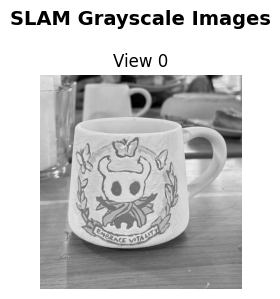

In [12]:
# Visualize a grid of images
n_show = min(16, len(image_data))
cols = 1
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 3*rows))
axes = axes.flatten() if n_show > 1 else [axes]

selected_random_image_indices = random.sample(range(len(image_data)), n_show)
for ax_idx, im_idx in enumerate(selected_random_image_indices):
    img = Image.open(io.BytesIO(image_data[im_idx])).convert('L')
    axes[ax_idx].imshow(np.array(img), cmap='gray')
    axes[ax_idx].set_title(f"View {im_idx}")
    axes[ax_idx].axis('off')

# Hide unused axes
for i in range(n_show, len(axes)):
    axes[i].axis('off')

plt.suptitle("SLAM Grayscale Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()